# Loading the repository from google drive


In [1]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive', force_remount = False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Installing some cool fonts

In [2]:
#################################################
# This cell install the fonts that im using in  #
# the plots, because colab does not have them   #
# as default. After runnin this cell you must   #
# restart the session and skip this cell in     #
# the next run                                  #
#################################################

!echo ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true | debconf-set-selections

#Update and install the fonts silently
!apt-get update -qq
!apt-get install -y -qq ttf-mscorefonts-installer

#Rebuild the system font cache
!fc-cache -fv

#Reliably clear the Matplotlib font cache
import matplotlib
import shutil
import os

cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)




W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package libmspack0:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-libmspack0_0.10.1-2build2_amd64.deb ...
Unpacking libmspack0:amd64 (0.10.1-2build2) ...
Selecting previously unselected package cabextract.
Preparing to unpack .../01-cabextract_1.9-3_amd64.deb ...
Unpacking cabextract (1.9-3) ...
Selecting previously unselected package xfonts-encodings.
Preparing to unpack .../02-xfonts-encodings_1%3a1.0.5-0ubuntu2_all.deb ...
Unpacking xfonts-encodings (1:1.0.5-0ubuntu2) ...
Selecting previously unselected package xfonts-utils.
Preparing to unpack .../03-xfonts-utils_1%3a7.7+6build2_amd64.deb ...
Unpacking xfonts-utils (1:7.7+6build2) ...
Selecting previously unselected package pyth

# Imports and configurations

In [10]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import importlib
import os
import scipy.stats as stats
from scipy.stats import chi2, norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import seaborn as sns

# Force-download the newest version of the helper file
!wget -q -O helper.py https://raw.githubusercontent.com/viniciusrocca/BSMandHypothesisTest/main/helper.py
import helper as hp

# Force-download the Z prime constraints:
!wget -q -O Safe_Limits_Zprime.csv https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/develop/Recast/Zprime/Safe_Limits_Zprime.csv

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 14, "axes.labelsize": 15, "axes.titlesize": 15,
    "legend.fontsize": 11, "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",  "mathtext.rm": "serif",
    "mathtext.it": "serif:italic", "mathtext.bf": "serif:bold",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}



plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['figure.max_open_warning'] = 50
pd.option_context('display.max_columns', -1)


pd.options.mode.chained_assignment = None #Disable copy warnings


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.9, rc={
    "axes.labelsize": 19,   # Increases the X and Y axis labels
    "axes.titlesize": 19,   # Increases the plot title
    "legend.title_fontsize": 14, # Optional: if you have a legend title
    "legend.fontsize": 13,
})
cm = plt.colormaps['RdYlBu']



# Loading the distributions

In [11]:
# Initialize loader and assemble base DataFrames
loader = hp.TTbarDataLoader(base_path='./drive/MyDrive/Distributions', lumi=500.0, zp_mass=3200)
loader.discover_files()
loader.build_baselines_and_scan(zp_limit_csv_path='Safe_Limits_Zprime.csv')

# These DataFrames contain unscaled base weights ready for any luminosity
df_bsm, df_sm = loader.assemble_dataframes()


--- File Discovery Check ---
VLF             files found: 43
Scalar          files found: 46
Zprime          files found: 41
Zprime_20pc     files found: 41
SM              files found: 8
FakeData        files found: 2
Fake Data correctly normalized to yield: 1935.91 in target window.

Running Mass Scans using Chi^2 minimization...

--- Global Best Fit Results (Chi^2 Minimization) ---
VLF         : Mass = 1700 GeV | yDM = 4.350043e+00 | Chi^2 = 0.40
Scalar      : Mass = 1500 GeV | yDM = 7.690103e+00 | Chi^2 = 0.01
Zprime      : Mass = 3200 GeV | yDM = 2.605812e-01 | Chi^2 = 11.14
Zprime_20pc : Mass = 3100 GeV | yDM = 3.755963e+00 | Chi^2 = 5.50
FakeData    : Mass = 1500 GeV | yDM = 7.690737e+00 | Chi^2 = 0.00

--- Assembling DataFrames ---
BSM Events: 4726052
SM Events:  6600000


# Binning and ploting the distributions

SM 
SM  628525.3905401826
FakeData | $m_\varphi=1500$ GeV | $m_\chi=1400$ GeV | $y_{DM}=7.69$
FakeData | $m_\varphi=1500$ GeV | $m_\chi=1400$ GeV | $y_{DM}=7.69$ 1935.9125484757533
VLF | $m_\psi=1700$ GeV | $m_\phi=1600$ GeV | $y_{DM}=4.35$
VLF | $m_\psi=1700$ GeV | $m_\phi=1600$ GeV | $y_{DM}=4.35$ 2111.657317358593
$Z^\prime$, $\Gamma_{Z^\prime} = 0.01m_{Z^\prime}$ | $m_{Z^\prime}=3200$ GeV | $\mu=0.26$
$Z^\prime$, $\Gamma_{Z^\prime} = 0.01m_{Z^\prime}$ | $m_{Z^\prime}=3200$ GeV | $\mu=0.26$ 54.22826138183882


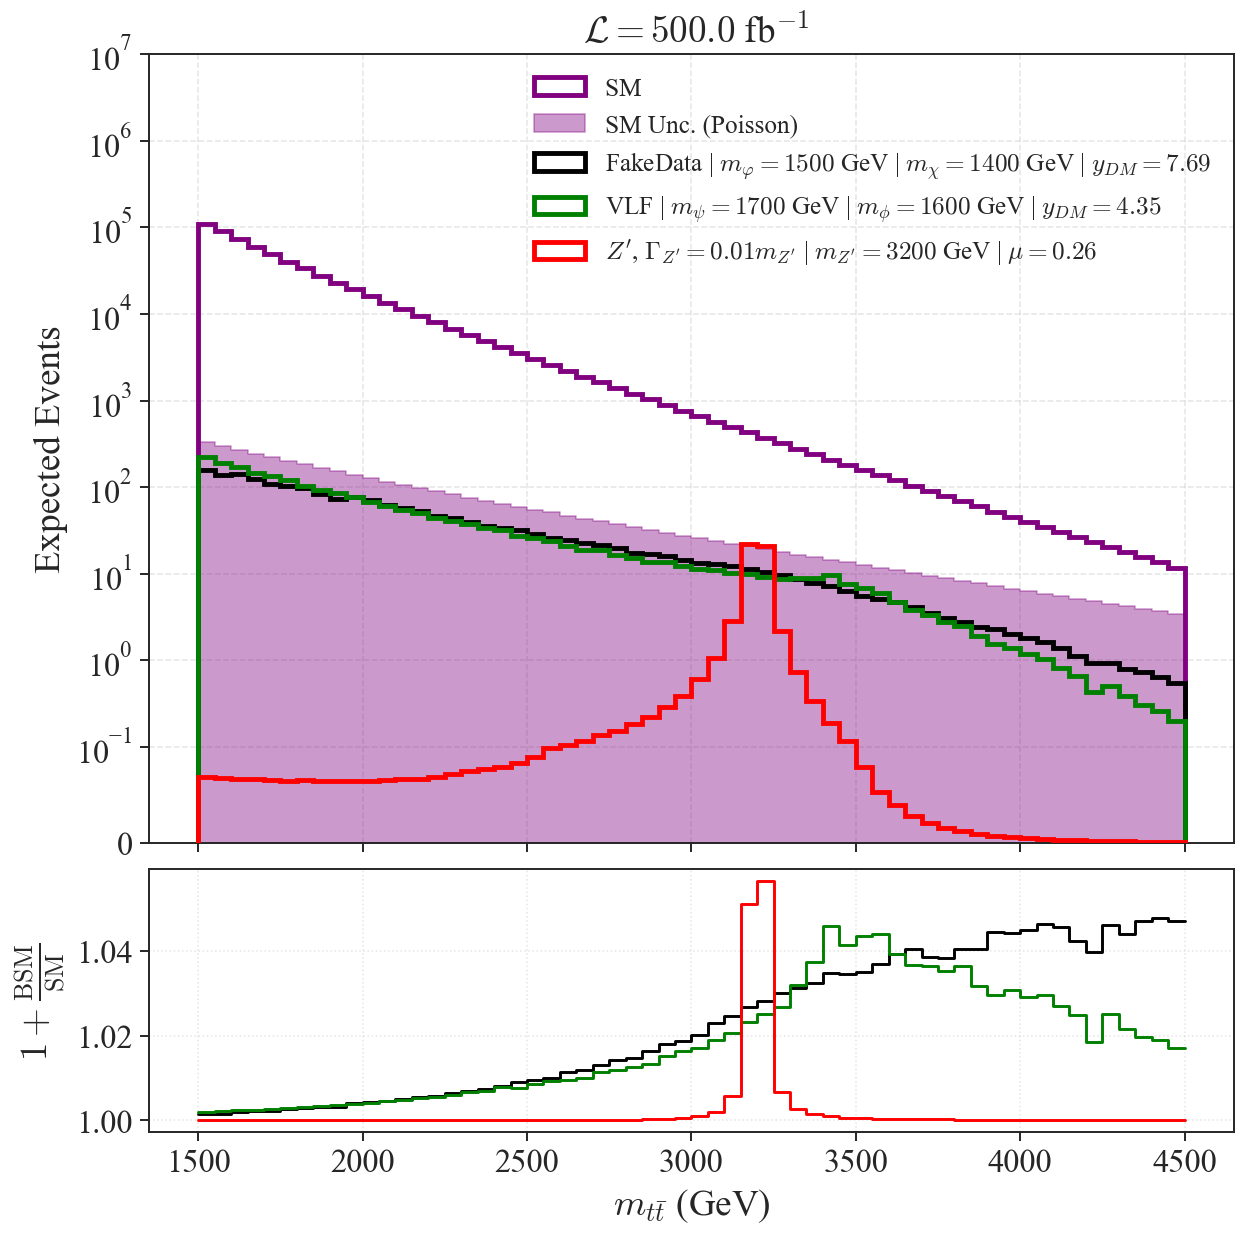

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_weighted_histograms(df_bsm, df_sm, var, fit_dict=None, lum=500.0, bins=60, rng=None, density=False, sys_err=0.05):
    """
    Plots superimposed 1D distributions (Main) and their ratio to SM (Sub-panel) with Error Bars.
    Distributions are plotted with their raw expected yields for the given luminosity.
    Negative weights (e.g., from NLO interference) are fully preserved.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", 'VLF', 'Zprime']

    # Dynamically Build Model Metadata from best_fits
    model_stats = {}
    if fit_dict is not None:
        if 'VLF' in fit_dict:
            m = fit_dict['VLF']['mPsiT']
            m1 = fit_dict['VLF']['mSDM']
            y = fit_dict['VLF']['scale_factor']
            model_stats['VLF'] = rf" | $m_\psi={m:.0f}$ GeV | $m_\phi={m1:.0f}$ GeV | $y_{{DM}}={y:.2f}$"

        if 'Scalar' in fit_dict:
            m = fit_dict['Scalar']['mST']
            m1 = fit_dict['Scalar']['mChi']
            y = fit_dict['Scalar']['scale_factor']
            model_stats['Scalar'] = rf" | $m_\varphi={m:.0f}$ GeV | $m_\phi={m1:.0f}$ GeV | $y_{{DM}}={y:.2f}$"

        if 'Zprime' in fit_dict:
            m = fit_dict['Zprime']['mZp']
            y = fit_dict['Zprime']['scale_factor']
            model_stats['Zprime'] = rf" | $m_{{Z^\prime}}={m:.0f}$ GeV | $\mu={y:.2f}$"


        if 'FakeData' in fit_dict:
            y = fit_dict['FakeData']['scale_factor']
            # FakeData gets hardcoded masses as requested
            model_stats['FakeData'] = rf" | $m_\varphi=1500$ GeV | $m_\chi=1400$ GeV | $y_{{DM}}={y:.2f}$"

    #Define Color Mapping Here
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        r'$Z^\prime$, $\Gamma_{Z^\prime} = 0.01m_{Z^\prime}$': 'red',
        r'$Z^\prime$, $\Gamma_{Z^\prime} = 0.2m_{Z^\prime}$': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # Extract and Bin SM
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_poisson = np.sqrt(h_sm)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)

    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'err_poisson': hErr_sm_poisson, 'lbl': f"SM "}

    # Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        # Append the dynamically extracted stats to the label
        stats = model_stats.get(lab_str, "")

        if lab_str == 'Zprime':
            lab_str = r'$Z^\prime$, $\Gamma_{Z^\prime} = 0.01m_{Z^\prime}$'
        elif lab_str == 'Zprime_20pc':
            lab_str = r'$Z^\prime$, $\Gamma_{Z^\prime} = 0.2m_{Z^\prime}$'

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)

        if lab_str == 'FakeData':
            err = np.sqrt(np.abs(h))
        else:
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)

        hist_data[lab_str] = {'h': h, 'err': err, 'lbl': f"{lab_str}{stats}"}

    # ------------------------------------------------------------
    # Setup Figure
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    for lab_str, data in hist_data.items():

        c = color_map.get(lab_str, 'gray')
        print(data['lbl'])

        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c, zorder=3)
        print(data['lbl'], sum(data['h']))

        if lab_str == 'SM':
            h_pad = np.append(data['h'], data['h'][-1])
            err_poisson_pad = np.append(data['err_poisson'], data['err_poisson'][-1])

            ax_main.fill_between(bin_edges, 0, err_poisson_pad, step='post', color=c, alpha=0.4, zorder=1, label=r"SM Unc. (Poisson)")

        if lab_str != 'SM':
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = 1 + np.where(h_sm > 0, data['h'] / h_sm, np.nan)
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / h_sm) * np.sqrt(data['err']**2 + (ratio**2 * hErr_sm**2)),
                    np.nan
                )

            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=1.0, zorder=3)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    ax_main.set_title(rf" $\mathcal{{L}} = {lum}$ fb$^{{-1}}$")
    ax_main.set_ylabel("Density" if density else "Expected Events")

    ax_main.legend(loc="upper right", framealpha=1.0)
    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)
    ax_main.set_ylim([0, 1e+7])

    ax_ratio.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var == 'm_tt' else var)
    ax_ratio.set_ylabel(r"$1 + \frac{\mathrm{BSM}}{\mathrm{SM}}$")
    ax_ratio.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [("m_tt", (1500, 4500))]
LUMI = 500.0
best_fits = {
    'VLF':    {'mPsiT': 1700.0, 'mSDM': 1600., 'scale_factor': 4.350046e+00},
    'Scalar': {'mST': 1500.0, 'mChi': 1500.0, 'scale_factor': 7.690102e+00},
    'Zprime': {'mZp': 3200.0, 'scale_factor': 2.605812e-01},
    'FakeData': {'scale_factor': 7.690102e+00}
}

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        fit_dict=best_fits,
        lum=LUMI,
        bins=60,
        rng=rng,
        density=False,
        sys_err=0.05
    )

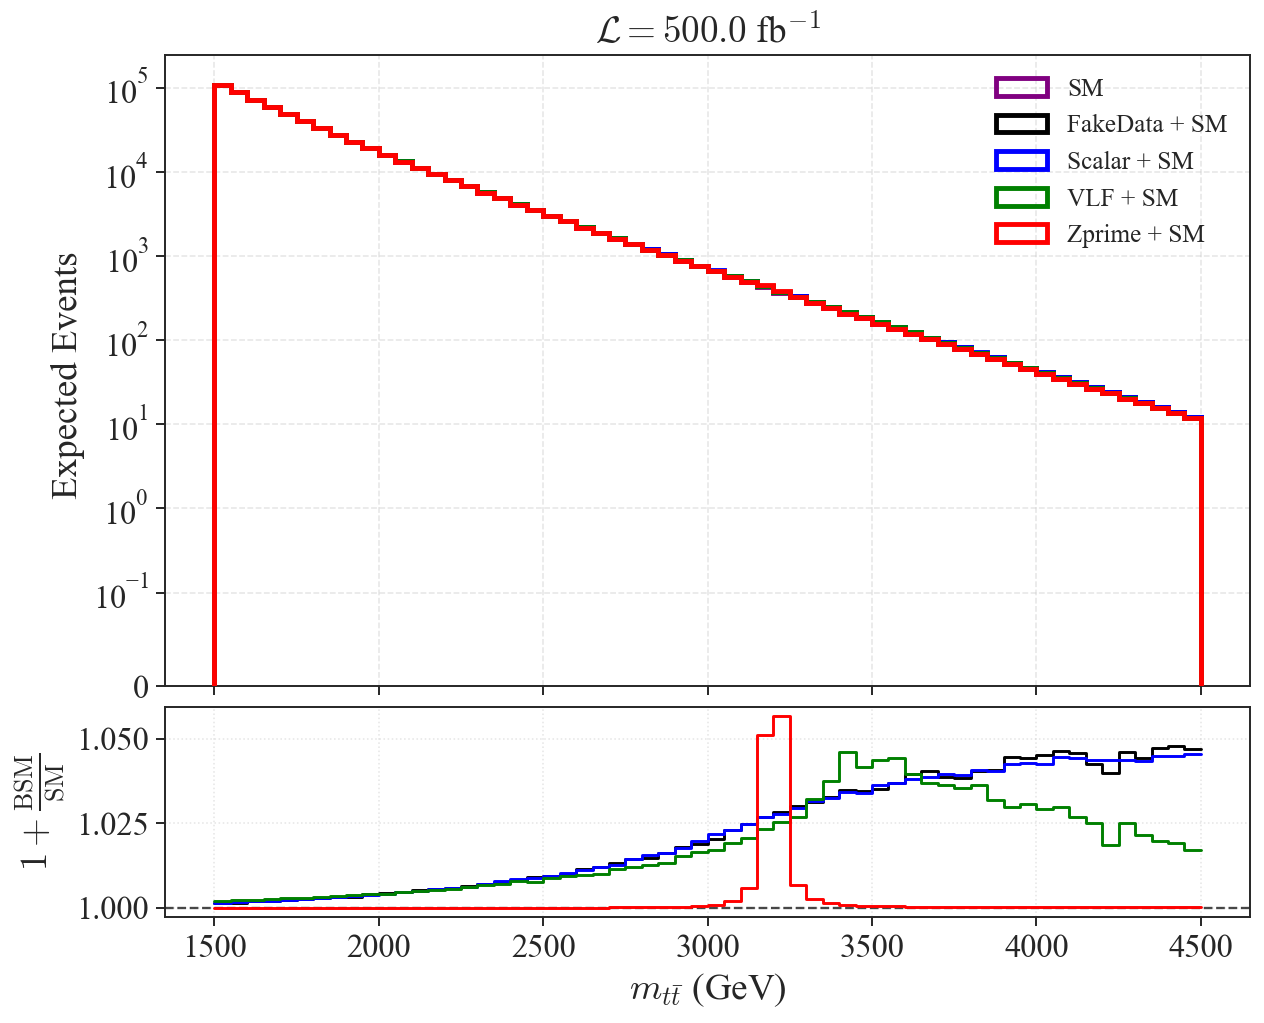

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_and_save_signal_plus_background(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.00):
    """
    Plots SM and (SM + BSM) superimposed 1D distributions and their ratio to SM.
    Returns a dictionary of bin distributions, total yields, and errors for subsequent Poisson sampling.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime"]

    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}


    saved_distributions = {
        'bin_edges': bin_edges,
        'bin_centers': bin_centers,
        'models': {}
    }

    # Extract and Bin SM
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_poisson = np.sqrt(np.abs(h_sm))
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # Apply SM Systematic Error
    hErr_sm = np.sqrt(hErr_sm_poisson**2 + (sys_err * h_sm)**2)

    hist_data['SM'] = {
        'h': h_sm,
        'err': hErr_sm,
        'err_poisson': hErr_sm_poisson,
        'lbl': f"SM"
    }

    # Save pure SM distributions
    saved_distributions['models']['SM'] = {
        'yields': h_sm,
        'err_total': hErr_sm,
        'err_stat_only': np.sqrt(hErr_sm_stat_sq)
    }

    # Extract, Bin, and Sum BSM Models (SM + BSM)
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h_bsm_only, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)
        err_bsm_only = np.sqrt(np.abs(h_bsm_only))

        #if lab_str == 'FakeData':
         #   err_bsm_only = np.sqrt(np.abs(h_bsm_only))
        #else:
         #   hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
          #  err_bsm_only = np.sqrt(hErr_stat_sq)

        # COMPUTE SM + BSM SUM AND COMBINED ERRORS
        h_total = h_sm + h_bsm_only
        err_total = np.sqrt(hErr_sm**2 + err_bsm_only**2)

        hist_data[lab_str] = {
            'h': h_total,
            'h_bsm_only': h_bsm_only,
            'err': err_total,
            'err_bsm_only': err_bsm_only,
            'lbl': f"{lab_str} + SM"
        }

        # Save SM + BSM distributions for Poisson sampling later
        saved_distributions['models'][lab_str] = {
            'yields_total': h_total,
            'yields_bsm_only': h_bsm_only,
            'err_total': err_total,
            'err_bsm_only': err_bsm_only
        }

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():
        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram (now represents SM + BSM for signal models)
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c, zorder=3)
        #ax_main.errorbar(bin_centers, np.abs(data['h']), yerr=data['err'], fmt='o', color=c, zorder=2, capsize = 4, markersize = 0)

        # SM Shaded Uncertainty Band
        if lab_str == 'SM':
            h_pad = np.append(data['h'], data['h'][-1])
            err_pad = np.append(data['err'], data['err'][-1])
            err_poisson_pad = np.append(data['err_poisson'], data['err_poisson'][-1])

            #ax_main.fill_between(bin_edges, 0, err_pad, step='post', color=c, alpha=0.3, zorder=2,
             #                    label=rf"SM Unc. (Sys {100*sys_err}%)")
            #ax_main.fill_between(bin_edges, 0, err_poisson_pad, step='post', color='gray', alpha=0.3, zorder=1,
             #                    label=r"SM Unc. (Poisson)")

            # Baseline for ratio panel
            ax_ratio.axhline(1.0, color='k', linestyle='--', alpha=0.8, zorder=1)

        # Compute and plot ratio: (SM + BSM) / SM
        else:
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)
                bsm_to_sm = data['h_bsm_only'] / h_sm
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / np.abs(h_sm)) * np.sqrt(data['err_bsm_only']**2 + (bsm_to_sm**2 * hErr_sm**2)),
                    np.nan
                )

            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=1.0, zorder=3)
            #ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color=c, zorder=2, capsize = 4, markersize = 0)
    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    ax_main.set_title(rf"$\mathcal{{L}} = {lum}$ fb$^{{-1}}$")
    ax_main.set_ylabel("Density" if density else "Expected Events ")
    ax_main.legend(loc="best", framealpha=1.0)
    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    ax_ratio.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var == 'm_tt' else var)
    ax_ratio.set_ylabel(r"$1 + \frac{ \mathrm{BSM}}{\mathrm{SM}}$")
    ax_ratio.grid(True, linestyle=':', alpha=0.5)
    #ax_ratio.set_ylim(0.99, 1.09)

    plt.tight_layout()
    plt.show()

    return saved_distributions

# Execution
observables = [("m_tt", (1500, 4500))]
LUMI = 500.0

for v, rng in observables:
    saved_data = plot_and_save_signal_plus_background(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=rng,
        density=False,
        sys_err=0.00
    )

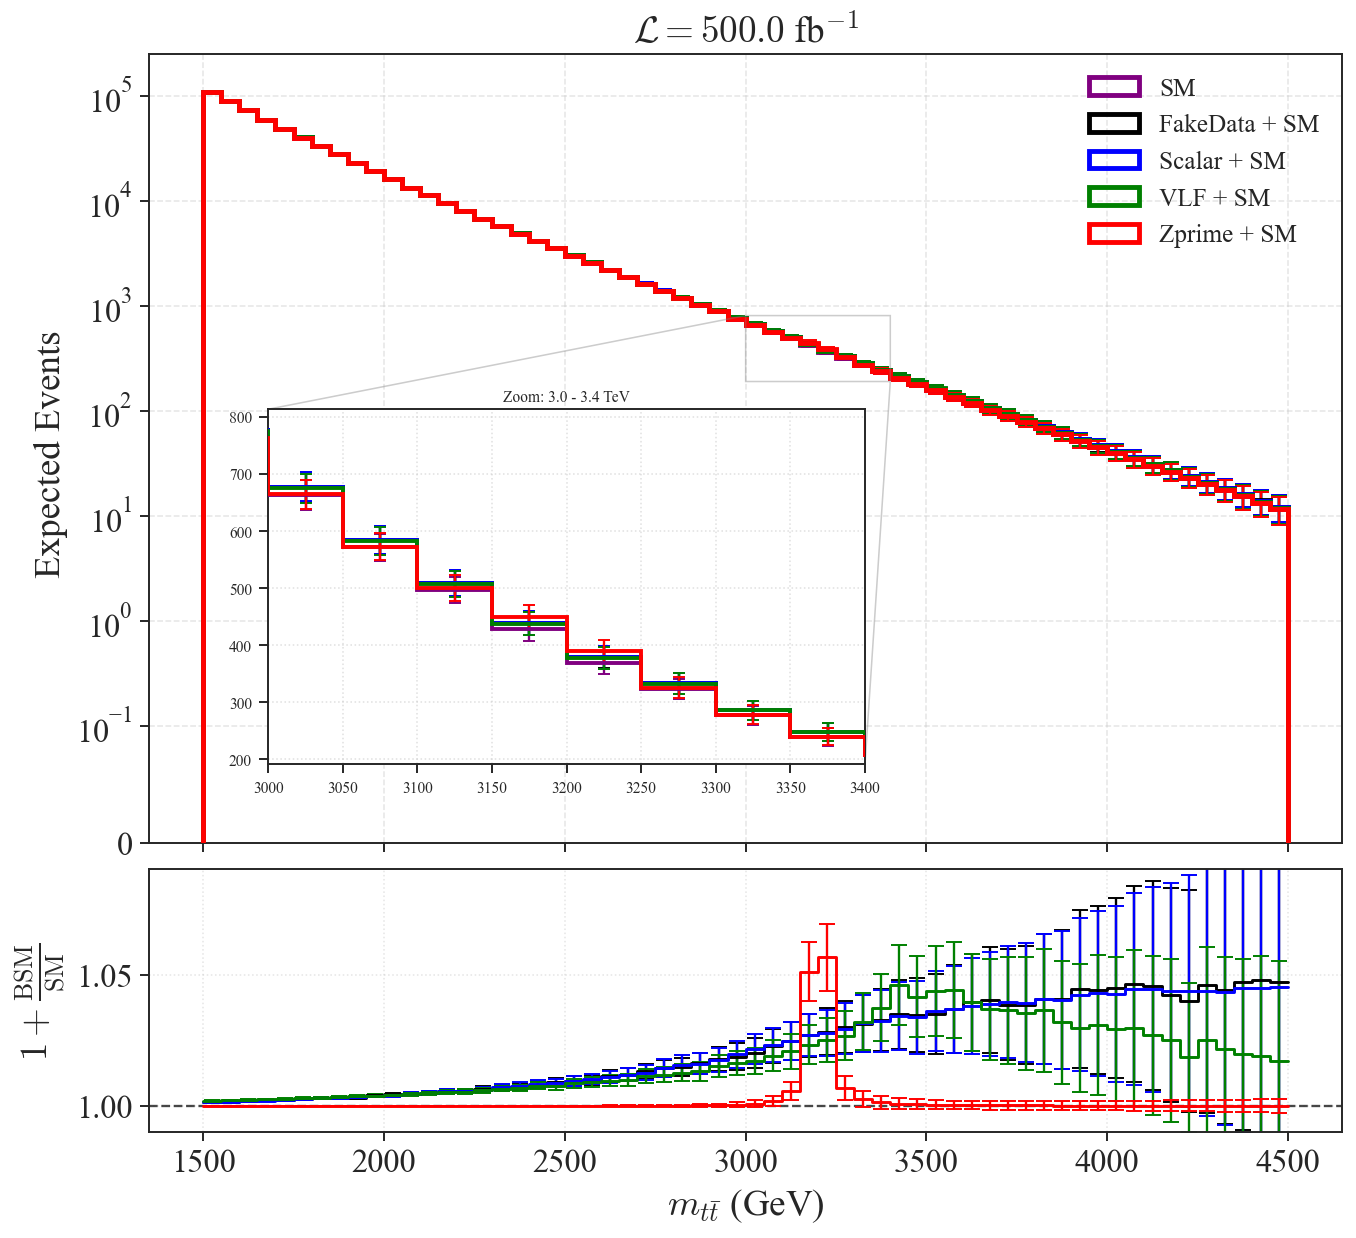

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_and_save_signal_plus_background(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.00, add_zoom=False):
    """
    Plots SM and (SM + BSM) superimposed 1D distributions and their ratio to SM.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime"]

    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    saved_distributions = {
        'bin_edges': bin_edges,
        'bin_centers': bin_centers,
        'models': {}
    }

    # Extract and Bin SM
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_poisson = np.sqrt(np.abs(h_sm))
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    hErr_sm = np.sqrt(hErr_sm_poisson**2 + (sys_err * h_sm)**2)

    hist_data['SM'] = {
        'h': h_sm,
        'err': hErr_sm,
        'err_poisson': hErr_sm_poisson,
        'lbl': f"SM"
    }

    saved_distributions['models']['SM'] = {
        'yields': h_sm,
        'err_total': hErr_sm,
        'err_stat_only': np.sqrt(hErr_sm_stat_sq)
    }

    # Extract, Bin, and Sum BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h_bsm_only, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)
        err_bsm_only = np.sqrt(np.abs(h_bsm_only))

        h_total = h_sm + h_bsm_only
        err_total = np.sqrt(hErr_sm**2 + err_bsm_only**2)

        hist_data[lab_str] = {
            'h': h_total,
            'h_bsm_only': h_bsm_only,
            'err': err_total,
            'err_bsm_only': err_bsm_only,
            'lbl': f"{lab_str} + SM"
        }

        saved_distributions['models'][lab_str] = {
            'yields_total': h_total,
            'yields_bsm_only': h_bsm_only,
            'err': err_total,
            'err_bsm_only': err_bsm_only
        }

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(11, 10), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    ax_ins = None
    if add_zoom and var == 'm_tt':
        ax_ins = ax_main.inset_axes([0.1, 0.1, 0.5, 0.45])

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():
        c = color_map.get(lab_str, 'gray')

        # Plot main panel
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c, zorder=3)
        ax_main.errorbar(bin_centers, np.abs(data['h']), yerr=data['err'], fmt='o', color=c, zorder=2, capsize=4, markersize=0)

        # Plot into the zoomed inset if active
        if ax_ins is not None:
            ax_ins.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                         histtype="step", linewidth=2.0, color=c, zorder=3)
            ax_ins.errorbar(bin_centers, np.abs(data['h']), yerr=data['err'], fmt='o', color=c, zorder=2, capsize=3, markersize=0)

        if lab_str == 'SM':
            ax_ratio.axhline(1.0, color='k', linestyle='--', alpha=0.8, zorder=1)
        else:
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)
                bsm_to_sm = data['h_bsm_only'] / h_sm
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / np.abs(h_sm)) * np.sqrt(data['err_bsm_only']**2 + (bsm_to_sm**2 * hErr_sm**2)),
                    np.nan
                )

            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=1.0, zorder=3)
            ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color=c, zorder=2, capsize=4, markersize=0)

    # ------------------------------------------------------------
    # Formatting Main & Ratio Panels
    # ------------------------------------------------------------
    ax_main.set_title(rf"$\mathcal{{L}} = {lum}$ fb$^{{-1}}$")
    ax_main.set_ylabel("Density" if density else "Expected Events ")
    ax_main.legend(loc="upper right", framealpha=1.0)
    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    ax_ratio.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var == 'm_tt' else var)
    ax_ratio.set_ylabel(r"$1 + \frac{ \mathrm{BSM}}{\mathrm{SM}}$")
    ax_ratio.grid(True, linestyle=':', alpha=0.5)
    ax_ratio.set_ylim(0.99, 1.09)

    # ------------------------------------------------------------
    # Zoom Inset Customization
    # ------------------------------------------------------------
    if ax_ins is not None:
        # Set limits for the zoom view
        zoom_min, zoom_max = 3000, 3400
        ax_ins.set_xlim(zoom_min, zoom_max)

        in_zoom = (bin_centers >= zoom_min) & (bin_centers <= zoom_max)
        y_values = [data['h'][in_zoom] for data in hist_data.values()]
        if len(y_values) > 0 and any(len(y) > 0 for y in y_values):
            y_min = min([y.min() for y in y_values if len(y) > 0]) * 0.8
            y_max = max([y.max() for y in y_values if len(y) > 0]) * 1.2
            ax_ins.set_ylim(y_min, y_max)

        ax_ins.set_yscale('linear')
        ax_ins.grid(True, linestyle=':', alpha=0.6)
        ax_ins.tick_params(axis='both', labelsize=8)
        ax_ins.set_title("Zoom: 3.0 - 3.4 TeV", fontsize=8, pad=4)

        ax_main.indicate_inset_zoom(ax_ins, edgecolor="gray", alpha=0.4)

    plt.tight_layout()
    plt.show()

    return saved_distributions

# Execution
observables = [("m_tt", (1500, 4500))]
LUMI = 500.0

for v, rng in observables:
    saved_data = plot_and_save_signal_plus_background(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=rng,
        density=False,
        sys_err=0.00, add_zoom = True
    )

Lumi     | Model    | Λ Teórico    | Λ Empírico   | Diff (%)   | Z (Teo)   | Z (Emp)  
100.0    | SM       | 2.64         | 2.65         | 0.43     % | 1.63  σ | 1.63  σ
100.0    | Zprime   | 2.62         | 2.63         | 0.32     % | 1.62  σ | 1.62  σ
100.0    | Scalar   | 0.01         | 0.02         | 170.17   % | 0.08  σ | 0.14  σ
100.0    | VLF      | 1.07         | 1.09         | 1.42     % | 1.03  σ | 1.04  σ
Lumi     | Model    | Λ Teórico    | Λ Empírico   | Diff (%)   | Z (Teo)   | Z (Emp)  
300.0    | SM       | 7.92         | 7.91         | 0.22     % | 2.81  σ | 2.81  σ
300.0    | Zprime   | 7.86         | 7.84         | 0.24     % | 2.80  σ | 2.80  σ
300.0    | Scalar   | 0.02         | 0.00         | 87.00    % | 0.14  σ | 0.05  σ
300.0    | VLF      | 3.21         | 3.19         | 0.60     % | 1.79  σ | 1.79  σ
Lumi     | Model    | Λ Teórico    | Λ Empírico   | Diff (%)   | Z (Teo)   | Z (Emp)  
500.0    | SM       | 13.21        | 13.19        | 0.08     % | 3.63  σ | 

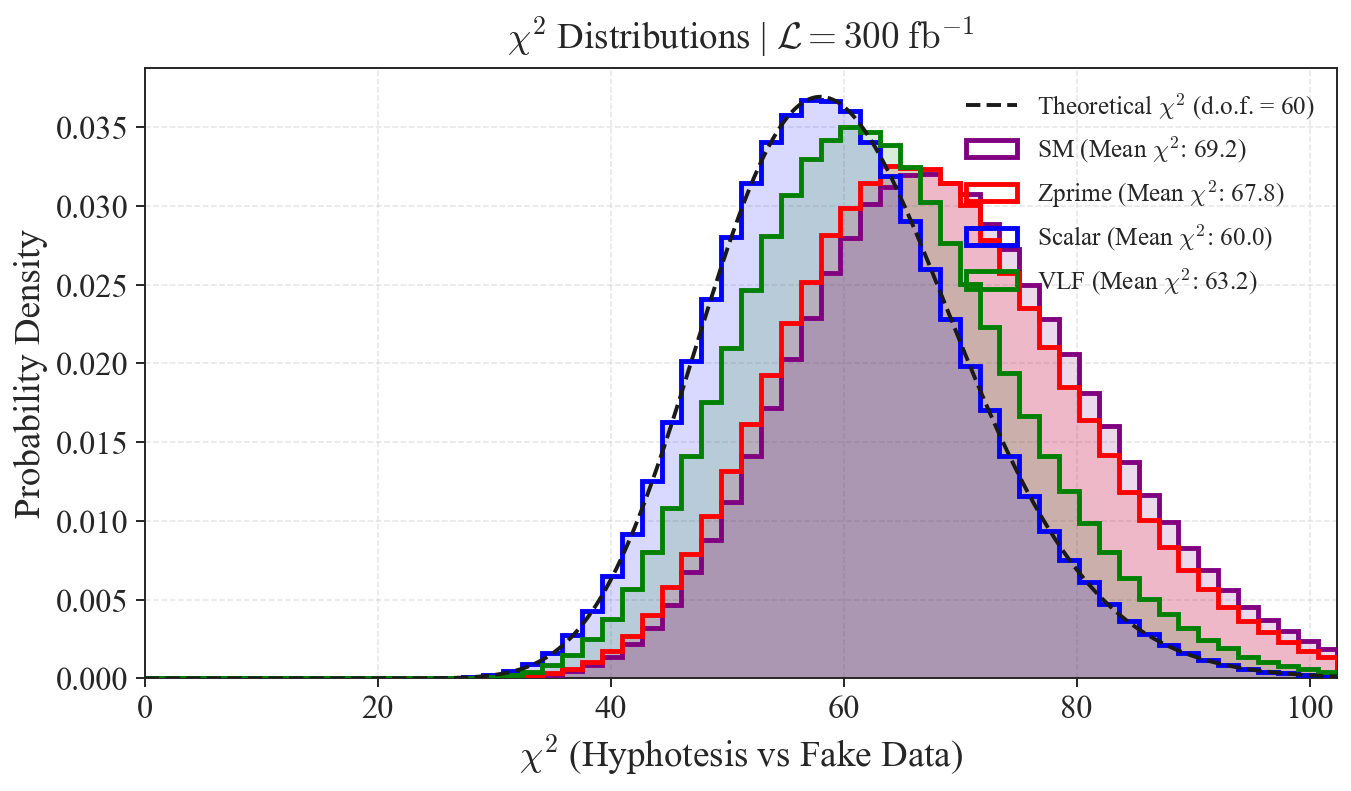

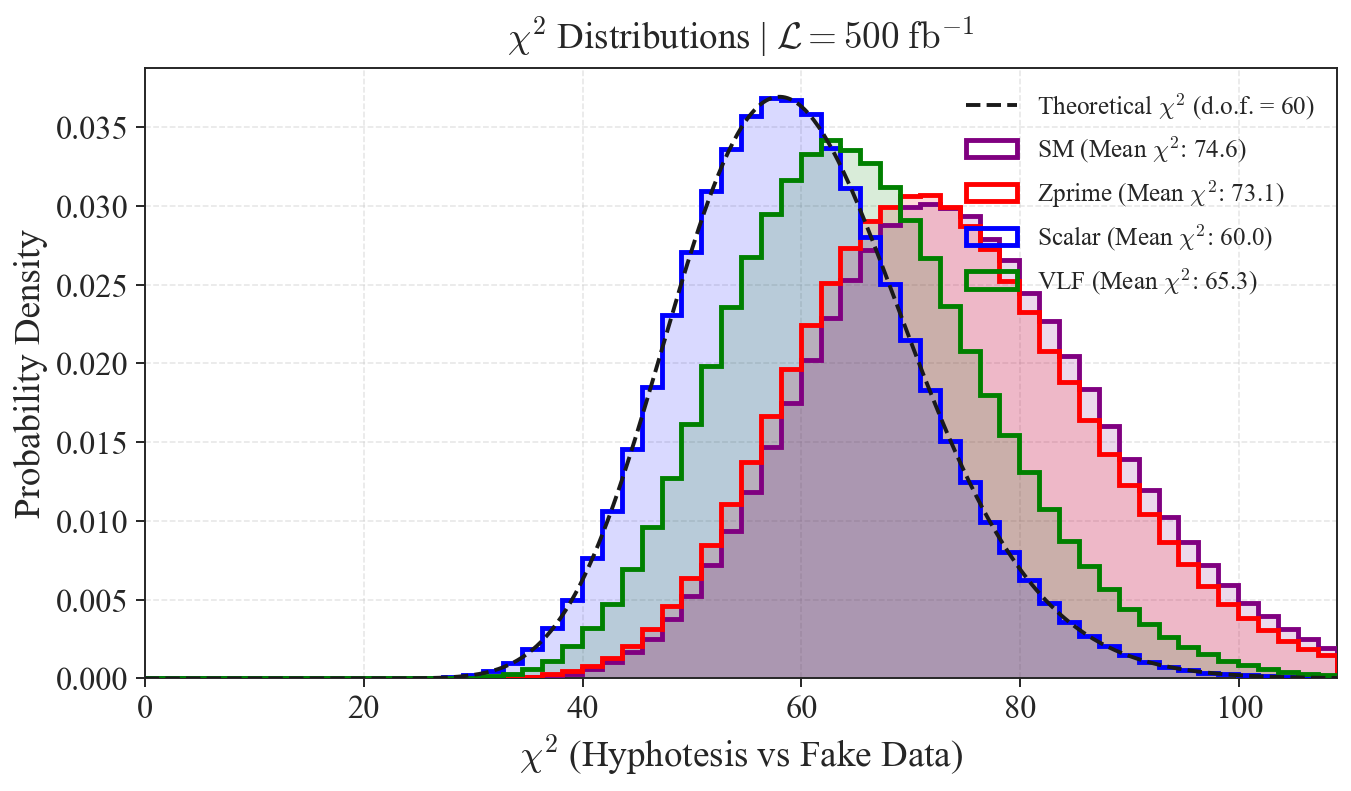

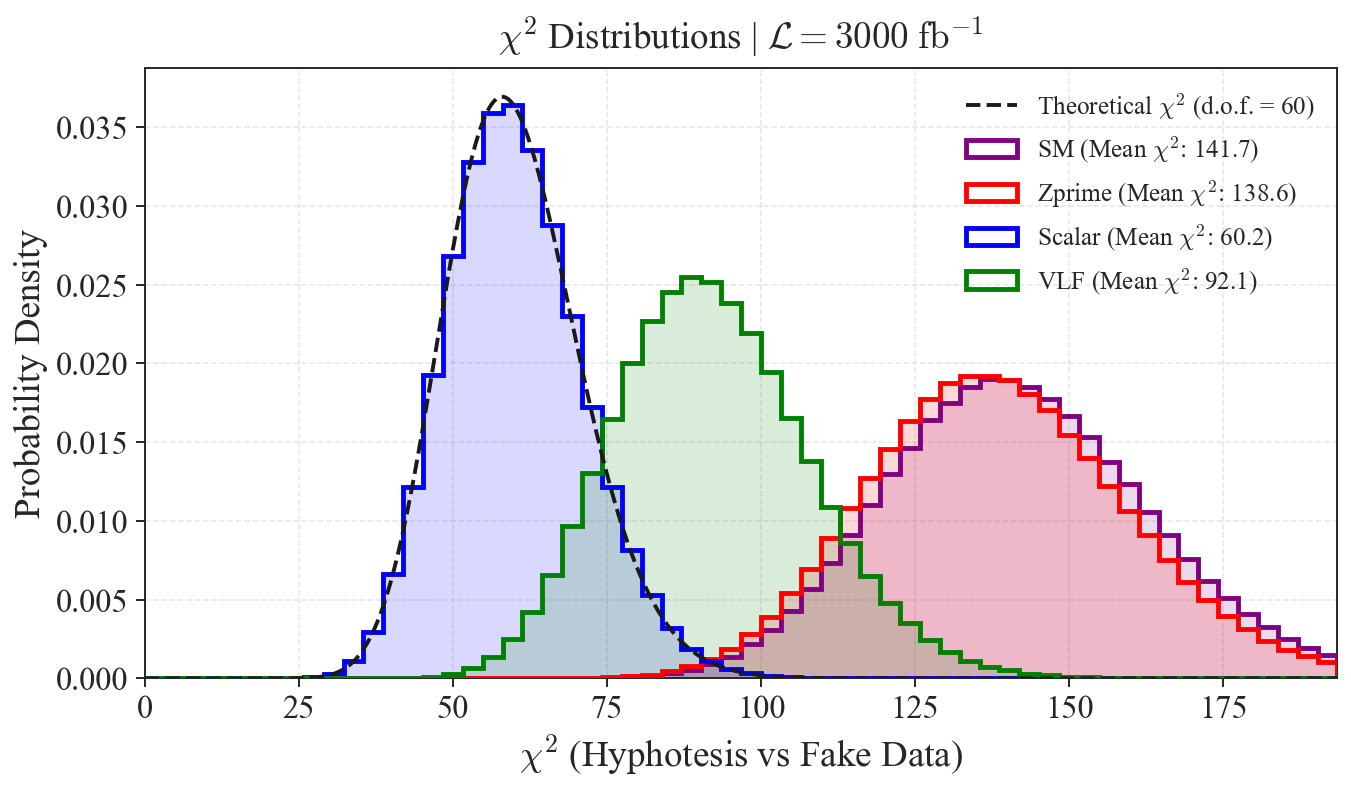

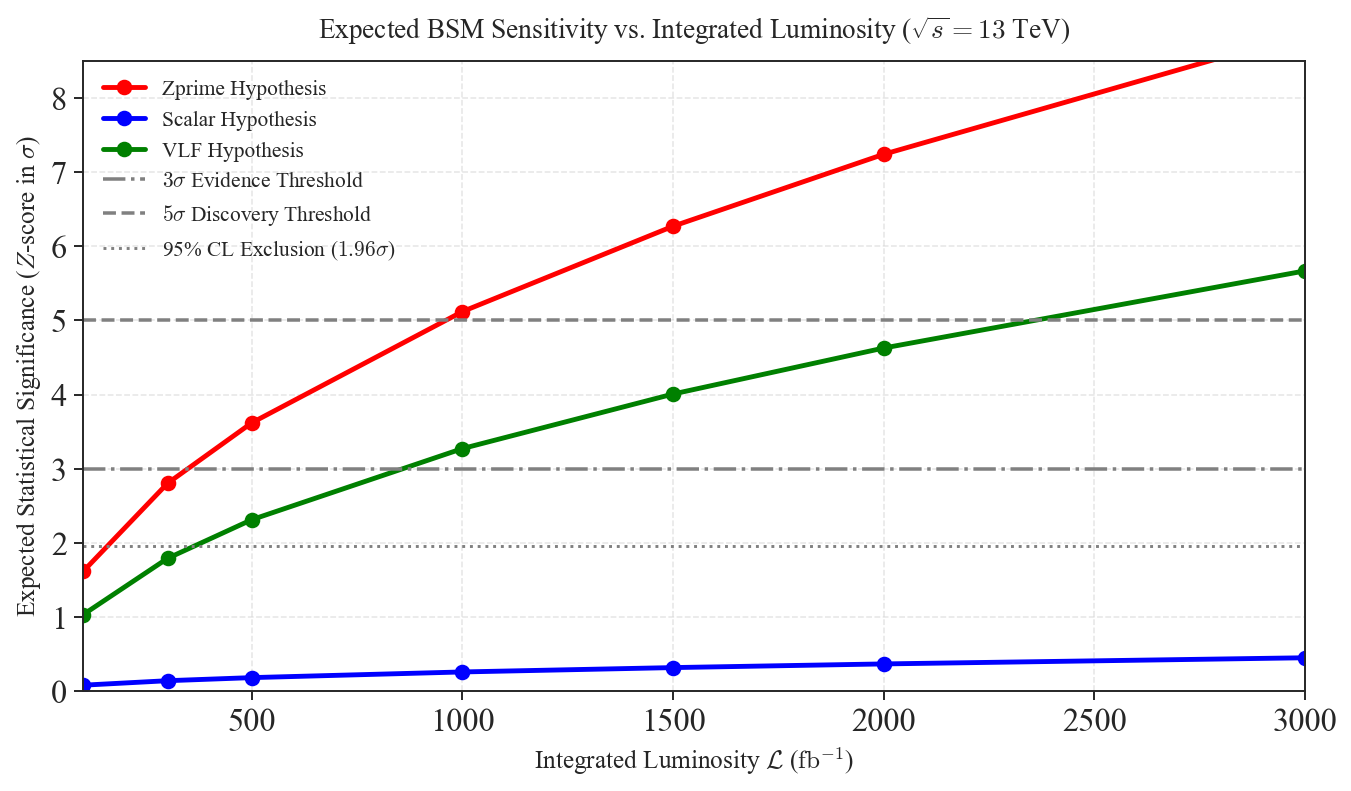

In [15]:


# Set global random seed for reproducible Poisson pseudo-experiments
np.random.seed(10739782)

# Define the luminosity range to scan (in fb^-1)
lumi_scan_points = [100.0, 300.0, 500.0, 1000.0, 1500.0, 2000.0, 3000.0]
models_to_test = ['SM', 'Zprime', 'Scalar', 'VLF']

# Dictionary to store tracking metrics for our final plot
scan_results = {model: {'lumi': [], 'mean_chi2': [], 'significance': [], 'p_val': []} for model in models_to_test}


chi2_lumi = {}
bins = 60
for L in lumi_scan_points:
    # Build binned distributions scaled to luminosity L
    saved_data = hp.HistogramBuilder.build_distributions(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var="m_tt",
        lum=L,
        bins=bins,
        rng=(1000, 4500),
        sys_err=0.00
    )

    # Extract FakeData as SM Background + BSM Signal (yields_total)
    fake_data_yields = saved_data['models']['FakeData']['yields_total']

    # Generate Poisson toys at luminosity L (only the fake data will be used
    toys_dict = {m: hp.StatEngine.generate_poisson_copies(saved_data, m, n_copies=1_000_000) for m in models_to_test + ['FakeData']}

    # Compute Chi^2 test statistics against FakeData
    chi2_dict = hp.StatEngine.compute_test_statistic(toys_dict, fake_data_yields, saved_data, variance_type='total_error')
    chi2_lumi[L] = chi2_dict
    # Evaluate significance and store metrics

    print("="*115)
    print(f"{'Lumi':<8} | {'Model':<8} | {'Λ Teórico':<12} | {'Λ Empírico':<12} | {'Diff (%)':<10} | {'Z (Teo)':<9} | {'Z (Emp)':<9}")
    print("="*115)

    for model in models_to_test:
        lbl = 'yields' if model == 'SM' else 'yields_total'
        expected_model = saved_data['models'][model][lbl]
        variance = saved_data['models']['FakeData']['err_total']**2

        # ---------------------------------------------------------
        #  Asimov dataset
        # ---------------------------------------------------------
        lambda_teo = np.sum((expected_model - fake_data_yields)**2 / variance)

        # ---------------------------------------------------------
        # Toy computations
        # ---------------------------------------------------------
        fake_toys = toys_dict['FakeData']

        # Chi2 of fake data toys vs the hypothesis
        chi2_empirico_array = np.sum((fake_toys - expected_model)**2 / variance, axis=1)

        # Non-centrality parameter is equals to the mean of chi2 distribution minus the number of degrees of freedom
        lambda_emp = np.mean(chi2_empirico_array) - bins

        # ---------------------------------------------------------
        # Results
        # ---------------------------------------------------------
        diff_percent = abs(lambda_teo - lambda_emp) / lambda_teo * 100 if lambda_teo > 0 else 0.0

        # Gaussian significance
        z_teo = np.sqrt(lambda_teo)
        z_emp = np.sqrt(lambda_emp) if lambda_emp > 0 else 0.0

        # Storing results
        scan_results[model]['lumi'].append(L)
        scan_results[model]['mean_chi2'].append(lambda_teo + bins)
        scan_results[model]['significance'].append(z_teo)


        print(f"{L:<8.1f} | {model:<8} | {lambda_teo:<12.2f} | {lambda_emp:<12.2f} | {diff_percent:<8.2f} % | {z_teo:<5.2f} σ | {z_emp:<5.2f} σ")

# ==============================================================================
# Chi^2 Distributions
# ==============================================================================

hp.ColliderPlotter.plot_chi2_distributions(chi2_lumi[300.0], n_bins_dof=bins, bins=60, lumi = 300)

hp.ColliderPlotter.plot_chi2_distributions(chi2_lumi[500.0], n_bins_dof=bins, bins=60, lumi = 500)

hp.ColliderPlotter.plot_chi2_distributions(chi2_lumi[3000.0], n_bins_dof=bins, bins=60, lumi = 3000)


# ==============================================================================
#  Expected Discovery Horizon (Significance vs. Luminosity)
# ==============================================================================
plt.figure(figsize=(10, 6))
color_map = {'SM': 'purple', 'Zprime': 'red', 'Scalar': 'blue', 'VLF': 'green'}

for model in models_to_test:
    if model == 'SM': continue
    lumis = scan_results[model]['lumi']
    sigmas = scan_results[model]['significance']
    c = color_map.get(model, 'black')
    plt.plot(lumis, sigmas, marker='o', linewidth=2.5, markersize=7, label=f"{model} Hypothesis", color=c)

# Add High-Energy Physics benchmark thresholds
plt.axhline(3.0, color='gray', linestyle='-.', linewidth=1.8, label=r"$3\sigma$ Evidence Threshold")
plt.axhline(5.0, color='gray', linestyle='--', linewidth=1.8, label=r"$5\sigma$ Discovery Threshold")
plt.axhline(1.96, color='gray', linestyle=':', linewidth=1.5, label=r"95% CL Exclusion ($1.96\sigma$)")

# Formatting
plt.title(r"Expected BSM Sensitivity vs. Integrated Luminosity ($\sqrt{s} = 13$ TeV)", fontsize=14, pad=12)
plt.xlabel(r"Integrated Luminosity $\mathcal{L}$ ($\mathrm{fb}^{-1}$)", fontsize=13)
plt.ylabel(r"Expected Statistical Significance ($Z$-score in $\sigma$)", fontsize=13)
plt.legend(loc="upper left", framealpha=0.9, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 8.5)
plt.xlim(min(lumi_scan_points), max(lumi_scan_points))

plt.tight_layout()
plt.show()